In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('titanic_clean.csv')
df.head()

,pclass,age,sibsp,parch,fare,survived
0,1,29,0,0,211.3375,1
1,1,0,1,2,151.5500,1
2,1,2,1,2,151.5500,0
3,1,30,1,2,151.5500,0
4,1,25,1,2,151.5500,0


## Additional Imports

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nColumn types:\n', df.dtypes)

Shape: (1309, 6)

Missing values:
 pclass      0
age         0
sibsp       0
parch       0
fare        0
survived    0
dtype: int64

Column types:
 pclass        int64
age           int64
sibsp         int64
parch         int64
fare        float64
survived      int64
dtype: object


## Feature Engineering

In [ ]:
# Title extraction from Name
if 'Name' in df.columns:
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    print('Titles found:', df['Title'].value_counts().to_dict())

# Family size
if 'SibSp' in df.columns and 'Parch' in df.columns:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    print('IsAlone distribution:', df['IsAlone'].value_counts().to_dict())

# Age bands
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                            labels=['Child','Teen','Adult','MidAge','Senior'])

# Fare bands
if 'Fare' in df.columns:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Low','Mid','High','VHigh'])

print('\nNew columns added. Shape now:', df.shape)


New columns added. Shape now: (1309, 6)


## Encoding & Cleaning

In [7]:
# Fill remaining nulls
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop low-value columns
drop_cols = [c for c in ['Name','Ticket','Cabin','PassengerId'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print('Dropped columns:', drop_cols)

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('\nFinal features:', df.columns.tolist())
df.head()

Dropped columns: []

Final features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived']


,pclass,age,sibsp,parch,fare,survived
0,1,29,0,0,211.3375,1
1,1,0,1,2,151.5500,1
2,1,2,1,2,151.5500,0
3,1,30,1,2,151.5500,0
4,1,25,1,2,151.5500,0


## Train / Test Split & Scaling

In [9]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Survival rate in train: {y_train.mean():.2%}')

Train size: 1047 | Test size: 262
Survival rate in train: 38.20%


## Train Multiple Models

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    test_acc = accuracy_score(y_test, preds)
    cv_acc   = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'Test Accuracy': test_acc, 'CV Accuracy': cv_acc}
    print(f'\n{name}')
    print(f'  Test Accuracy : {test_acc:.4f}')
    print(f'  CV Accuracy   : {cv_acc:.4f}')

print('\nBest model so far:', max(results, key=lambda k: results[k]['Test Accuracy']))


Logistic Regression
  Test Accuracy : 0.6908
  CV Accuracy   : 0.6896

Random Forest
  Test Accuracy : 0.6794
  CV Accuracy   : 0.6848

Gradient Boosting
  Test Accuracy : 0.6870
  CV Accuracy   : 0.7220

Best model so far: Logistic Regression


## Hyperparameter Tuning (Random Forest)

In [11]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
print('\n── Best Random Forest ──')
print('Best Params  :', grid.best_params_)
print('Test Accuracy:', accuracy_score(y_test, best.predict(X_test)))
print('\nClassification Report:')
print(classification_report(y_test, best.predict(X_test)))

Fitting 5 folds for each of 72 candidates, totalling 360 fits

── Best Random Forest ──
Best Params  : {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Test Accuracy: 0.7022900763358778

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.83      0.77       162
           1       0.64      0.50      0.56       100

    accuracy                           0.70       262
   macro avg       0.68      0.66      0.67       262
weighted avg       0.69      0.70      0.69       262



## Feature Importance

Top Features:
fare      0.394528
age       0.226107
pclass    0.170159
sibsp     0.106910
parch     0.102297


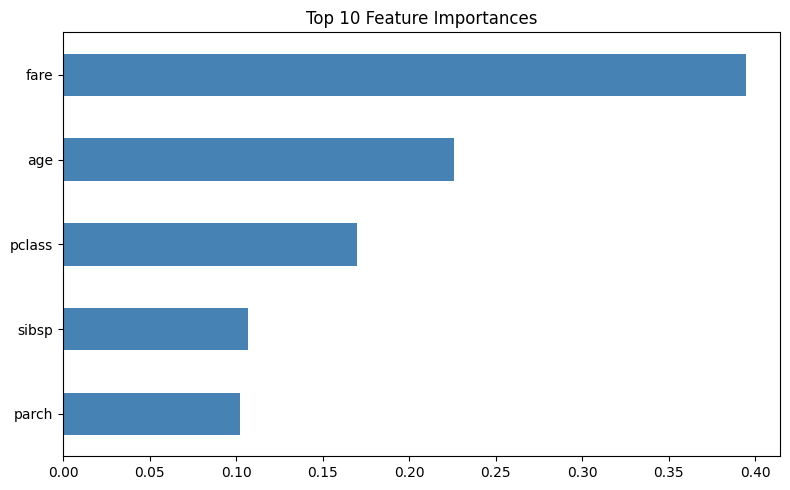

In [12]:
importance = pd.Series(best.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=False)

print('Top Features:')
print(importance_sorted.head(10).to_string())

# Plot
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    importance_sorted.head(10).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 10 Feature Importances')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
except ImportError:
    print('Install matplotlib to see the chart.')